# Lab 2 Naive Bayes Classification with Dummy Data

## Step 1 - Create Dummy Dataset

In [3]:
import numpy as np
from sklearn.datasets import make_classification

# Create dummy data
# The output of make_classification consists of feature data X and labels y
# The labels y will be encoded (numerical) data
X,y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_repeated=0, shuffle=False)

# By default, make_classification produces float values
# We need to convert them to discrete form

# Take the absolute value of the values
X = np.absolute(X)

# Round values to two decimal places
# Multiply by 100 so that there are no decimal points
X = np.round(X, 2) * 100

# Convert to integer type
X = X.astype(int)

# Check the result
print(X)
print(y)

[[160 190]
 [ 67  59]
 [114 113]
 [262 339]
 [163 186]
 [ 68 136]
 [109 113]
 [109 115]
 [ 54 204]
 [ 14 288]
 [112  74]
 [103  94]
 [ 74 166]
 [167  28]
 [113  86]
 [162   7]
 [ 53 138]
 [194   5]
 [ 90 112]
 [ 69 126]
 [139  67]
 [ 49 175]
 [149  41]
 [125  33]
 [145 190]
 [145  83]
 [ 59 159]
 [126  53]
 [ 33 274]
 [142  53]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


## Step 2 (Optional) - Create DataFrame

In [14]:
import pandas as pd

# Reshape label y into 2D
# This is done because we will concatenate it with the feature data X
y_new = y.reshape(len(y), 1)

# Concatenate features X and label y into an array
data = np.concatenate((X, y_new), axis=1)

# Define column names
nama_kolom = ['Feature 1', 'Feature 2', 'Label']

# Create DataFrame
df = pd.DataFrame(data, columns=nama_kolom)

# Inspect the DataFrame
df.head()

,Feature 1,Feature 2,Label
0,160,190,0
1,67,59,0
2,114,113,0
3,262,339,0
4,163,186,0


## Step 3 (Optional) - Labeling

In [17]:
# Define label names
labels = {
    1 : 'Class A',
    0 : 'Class B'
}

# Copy the DataFrame to create a new DataFrame
# with more readable labels
df_label = df.copy()

# Replace labels using the Pandas mapping function
# on the df_label DataFrame
df_label['Label'] = df_label['Label'].map(labels)

# Inspect the df_label DataFrame
df_label.head()

,Feature 1,Feature 2,Label
0,160,190,Class B
1,67,59,Class B
2,114,113,Class B
3,262,339,Class B
4,163,186,Class B


## Step 4 - Data Visualization

In [5]:
print(df_label['Label'].unique())

<ArrowStringArray>
['Class B', 'Class A']
Length: 2, dtype: str


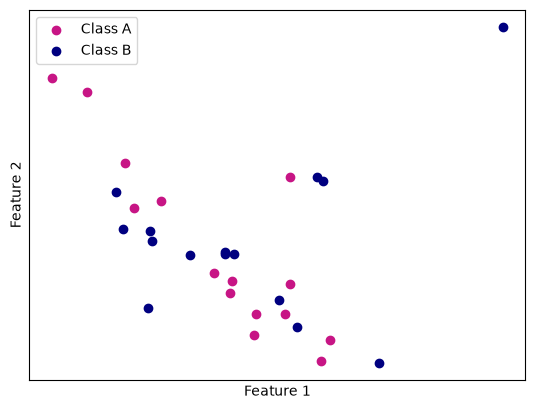

In [12]:
import matplotlib.pyplot as plt

colors = {
    'Class A': 'MediumVioletRed',
    'Class B': 'Navy'
}

# Group by column string directly (no list brackets)
gb = df_label.groupby('Label')
class_a = gb.get_group('Class A')
class_b = gb.get_group('Class B')

# Plot
plt.scatter(x=class_a['Feature 1'], y=class_a['Feature 2'], c=colors['Class A'], label='Class A')
plt.scatter(x=class_b['Feature 1'], y=class_b['Feature 2'], c=colors['Class B'], label='Class B')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Clean tick removal
plt.xticks([])
plt.yticks([])

plt.show()

## Step 5 - Multinomial Naive Bayes Model

In [13]:
from sklearn.naive_bayes import MultinomialNB # class for the MultinomialNB model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score # evaluate the model using accuracy

# Instantiate a MultinomialNB object
mnb = MultinomialNB()

# We can directly use the feature matrix X and labels y
# resulting from the dummy data generation process

# Split training and testing data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=30)

# Fit the model
# The label y must be in 1D form or (n_samples,)
mnb.fit(X_train, y_train)

# Predict on training data
y_train_pred = mnb.predict(X_train)

# Evaluate training accuracy
acc_train = accuracy_score(y_train, y_train_pred)

# Predict test data
y_test_pred = mnb.predict(X_test)

# Evaluate the model using the accuracy metric
acc_test = accuracy_score(y_test, y_test_pred)

# Print evaluation results
print(f'Training accuracy: {acc_train}')
print(f'Test accuracy: {acc_test}')

Training accuracy: 0.7619047619047619
Test accuracy: 0.5555555555555556
